<a href="https://colab.research.google.com/github/Pensive1881/DSR44_2025/blob/main/N2_Theta_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Theta Model

> _This paper presents a new univariate forecasting method. The method is based on the concept of modifying the local curvature of the time-series through a coefficient ‘Theta’ (the Greek letter θ), that is applied directly to the second differences of the data. The resulting series that are created maintain the mean and the slope of the original data but not their curvatures. These new time series are named Theta-lines. Their primary qualitative characteristic is the improvement of the approximation of the long-term behavior of the data or the augmentation of the short-term features, depending on the value of the Theta coefficient. The proposed method decomposes the original time series into two or more different Theta-lines. These are extrapolated separately and the subsequent forecasts are combined. The simple combination of two Theta-lines, the Theta=0 (straight line) and Theta=2 (double local curves) was adopted in order to produce forecasts for the 3003 series of the M3 competition. The method performed well, particularly for monthly series and for microeconomic data._
>
> Source: [The theta model: a decomposition approach to forecasting](https://www.researchgate.net/publication/223049702_The_theta_model_A_decomposition_approach_to_forecasting)

Although talking about "modifying the local curvature" may seem intimidating at first, the general idea behind the theta model and theta transformations is rather simple. It is a weighted sum of the original values, and a fitted linear regression. That's it. The weights - which have to add up to one - are determined by the parameter *theta* - hence the name of the model.

$$
\Large
\theta y_t + (1 - \theta)(a+bt)
$$

We can take a few theta values and apply them to the simple equation above to understand their effect:

$$
\Large
\begin{array}
\ &\theta = 0 &\implies a + bt
\\
\ &\theta = 1 &\implies y_t
\\
\ &\theta = 0.5 &\implies \frac{y_t}{2} + \frac{a + bt}{2}
\\
\ &\theta = 2 &\implies 2 y_t - (a + bt) = 2y_t - \theta_0
\end{array}
$$

See? Theta equals zero is simply a linear regression. Theta equals one is the original data. Theta equals 0.5 is the average between the two. Things get more interesting when we set theta to values higher than one.

All of those are called "theta-lines."

For theta equals two, we're "doubling local curves" by simply doubling the original values and subtracting the fitted values of the linear regression. It's as simple as that.

The proposed Theta Model itself is a simple combination of two theta-lines: theta zero and theta two. Guess what happens when we combine them?

$$
\Large
\frac{\theta_0 + \theta_2}{2} = \frac{\theta_0 + (2y_t - \theta_0)}{2} = \frac{2y_t}{2} = y_t
$$

That's right, we get the original values back! You can think of the theta model as an "ensemble" of two models, one that underfits the data (theta zero, the linear regression) and one that overfits the data (theta two). By averaging them, we should get closer to the original data whenever we make a forecast.

Let's load some airline data and compute some theta lines:

In [ ]:
!pip install sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.2/136.2 kB 9.0 MB/s eta 0:00:00


In [ ]:
from matplotlib import pyplot as plt
from sktime.datasets import load_airline

y = load_airline()

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.arange(len(y)).reshape(-1, 1)
lin0 = LinearRegression()
lin0.fit(X, y)
lin0.coef_, lin0.intercept_

(array([2.65718391]), 90.30996168582371)

In [ ]:
line_theta0 = lin0.predict(X)
line_theta0[-10:]

array([446.37260536, 449.02978927, 451.68697318, 454.34415709,
       457.001341  , 459.6585249 , 462.31570881, 464.97289272,
       467.63007663, 470.28726054])

In [ ]:
line_theta2 = 2*y.values - line_theta0
line_theta2[-10:]

array([391.62739464, 472.97021073, 492.31302682, 615.65584291,
       786.998659  , 752.3414751 , 553.68429119, 457.02710728,
       312.36992337, 393.71273946])

In [ ]:
# that's the theta model
(line_theta0 + line_theta2)/2

array([112., 118., 132., 129., 121., 135., 148., 148., 136., 119., 104.,
       118., 115., 126., 141., 135., 125., 149., 170., 170., 158., 133.,
       114., 140., 145., 150., 178., 163., 172., 178., 199., 199., 184.,
       162., 146., 166., 171., 180., 193., 181., 183., 218., 230., 242.,
       209., 191., 172., 194., 196., 196., 236., 235., 229., 243., 264.,
       272., 237., 211., 180., 201., 204., 188., 235., 227., 234., 264.,
       302., 293., 259., 229., 203., 229., 242., 233., 267., 269., 270.,
       315., 364., 347., 312., 274., 237., 278., 284., 277., 317., 313.,
       318., 374., 413., 405., 355., 306., 271., 306., 315., 301., 356.,
       348., 355., 422., 465., 467., 404., 347., 305., 336., 340., 318.,
       362., 348., 363., 435., 491., 505., 404., 359., 310., 337., 360.,
       342., 406., 396., 420., 472., 548., 559., 463., 407., 362., 405.,
       417., 391., 419., 461., 472., 535., 622., 606., 508., 461., 390.,
       432.])

Of course, we don't have to do it manually, many packages implement theta-lines, such as SkTime:

In [ ]:
from sktime.transformations.series.theta import ThetaLinesTransformer

transformer = ThetaLinesTransformer([0, 1.0, 0.5, 2.0])
y_thetas = transformer.fit_transform(y)

AttributeError: module 'dask' has no attribute 'dataframe'

In [ ]:
y_thetas

,0.0,1.0,0.5,2.0
Period,,,,
1949-01,90.309962,112.0,101.154981,133.690038
1949-02,92.967146,118.0,105.483573,143.032854
1949-03,95.624330,132.0,113.812165,168.375670
1949-04,98.281513,129.0,113.640757,159.718487
1949-05,100.938697,121.0,110.969349,141.061303
...,...,...,...,...
1960-08,459.658525,606.0,532.829262,752.341475
1960-09,462.315709,508.0,485.157854,553.684291
1960-10,464.972893,461.0,462.986446,457.027107


We can also plot all theta lines. An image is worth a thousand words, and this is especially true in this case:

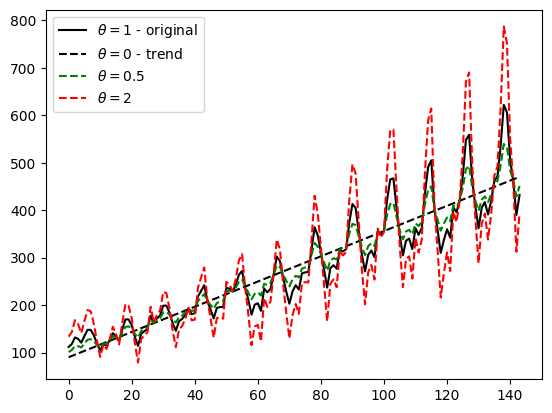

In [ ]:
from matplotlib import pyplot as plt
plt.plot(y_thetas[1].values, label=r'$\theta=1$ - original', c='k')
plt.plot(y_thetas[0].values, label=r'$\theta=0$ - trend', c='k', linestyle='--')
plt.plot(y_thetas[0.5].values, label=r'$\theta=0.5$', c='g', linestyle='--')
plt.plot(y_thetas[2].values, label=r'$\theta=2$', c='r', linestyle='--')
plt.legend()

The theta-line for theta equals two looks like an exaggerated version of the original data with more pronounced peaks and valleys. That's what "doubling the local curvature" of the data does.

## Forecasting

How can we make a forecast using the theta model? We have to make a forecast for each one of the lines, and them combine the forecasts.

The forecast for the theta zero line is straightforward, since it's just a linear regression:

In [ ]:
theta0_pred = lin0.predict(np.array([142, 143, 144, 145, 146]).reshape(-1, 1))
theta0_pred

array([467.63007663, 470.28726054, 472.94444444, 475.60162835,
       478.25881226])

For theta two line, however, we need to use something else. How about our old friend exponential smoothing?

In [ ]:
from sktime.forecasting.exp_smoothing import ExponentialSmoothing

ses = ExponentialSmoothing(smoothing_level=0.995,
                           initial_level=118.4666666666666,
                           initialization_method='known')
ses.fit(y_thetas[2])

/usr/local/lib/python3.10/dist-packages/pandas/util/_decorators.py:211: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


ExponentialSmoothing(initial_level=118.4666666666666,
                     initialization_method='known', smoothing_level=0.995)

Don't mind the smoothing and initial levels just yet, you'll understand why I used those shortly.

Now, we can make a forecast for the theta two line:

In [ ]:
theta2_pred = ses.predict([-1, 0, 1, 2, 3])
theta2_pred

1960-11    457.515364
1960-12    313.095651
1961-01    393.309654
1961-02    393.309654
1961-03    393.309654
Freq: M, Name: 2.0, dtype: float64

Now, we can combine them:

In [ ]:
(theta0_pred + theta2_pred)/2

1960-11    462.572720
1960-12    391.691456
1961-01    433.127049
1961-02    434.455641
1961-03    435.784233
Freq: M, Name: 2.0, dtype: float64

Seems like a lot of work to do it manually, right? We can use SkTime's `ThetaModularForecaster` instead:

In [ ]:
from sktime.forecasting.theta import ThetaModularForecaster
from sktime.forecasting.trend import PolynomialTrendForecaster

forecaster1 = ThetaModularForecaster(
     forecasters=[
         ("trend", PolynomialTrendForecaster(degree=1), 0),
         ("ses", ExponentialSmoothing(smoothing_level=0.995,
                                      initial_level=118.4666666666666,
                                      initialization_method='known'), 2),
     ],
     theta_values=(0, 2),
)
forecaster1.fit(y)
y_pred = forecaster1.predict(fh=range(-142, 4))
y_pred

/usr/local/lib/python3.10/dist-packages/pandas/util/_decorators.py:211: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


1949-02    113.290534
1949-03    119.305045
1949-04    133.265117
1949-05    130.349918
1949-06    122.375342
              ...    
1960-11    462.572720
1960-12    391.691456
1961-01    433.127049
1961-02    434.455641
1961-03    435.784233
Freq: M, Name: Number of airline passengers, Length: 146, dtype: float64

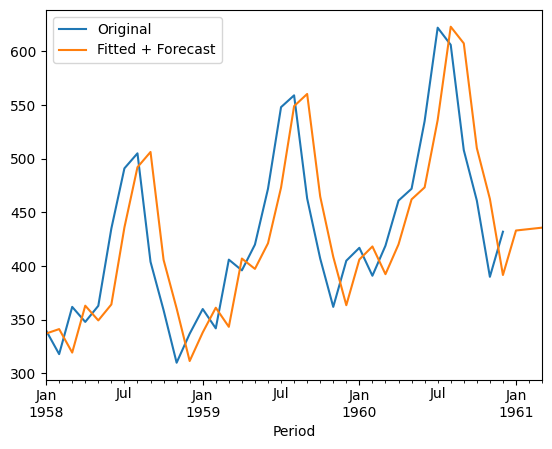

In [ ]:
y[-36:].plot(label='Original')
y_pred[-39:].plot(label='Fitted + Forecast')
plt.legend()

Does it look familiar? Let's take a look at what's happening with the forecasted values:

In [ ]:
y_pred[-3:].diff()

1961-01         NaN
1961-02    1.328592
1961-03    1.328592
Freq: M, Name: Number of airline passengers, dtype: float64

They're increasing linearly and, moreover, the change between every two time intervals is exactly half the slope of the linear regression.

In [ ]:
lin0.coef_/2

array([1.32859195])

As it turns out, the theta model is an overcomplicated version of something much simpler...

## Unmasking the Theta Method

> _We examine the Theta method and show that it can be expressed much more simply
than in A&N; furthermore we show that the forecasts obtained are equivalent to simple
exponential smoothing (SES) with drift._
>
> Source: [Unmasking the Theta Method](https://robjhyndman.com/papers/Theta.pdf)

Even though the general idea of the theta method/model looks reasonably intuitive, it was demonstrated shortly after that it boils down to our old friend exponential smoothing with drift.

And that's what SkTime's `ThetaForecaster` implements, let's try it out:

In [ ]:
from sktime.forecasting.theta import ThetaForecaster

forecaster2 = ThetaForecaster(deseasonalize=False, sp=1)
forecaster2.fit(y)

ThetaForecaster(deseasonalize=False)

By the way, take a quick look at the smoothing and initial levels estimated by the theta forecaster itself:

In [ ]:
forecaster2._fitted_forecaster.params

{'smoothing_level': 0.9999999850988388,
 'smoothing_trend': nan,
 'smoothing_seasonal': nan,
 'damping_trend': nan,
 'initial_level': 112.00000009205787,
 'initial_trend': nan,
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

Now you know why I used those values before, when we tried our own exponential smoothing model.

Let's make a forecast now:

In [ ]:
y_pred2 = forecaster2.predict(fh=range(-142, 4))
y_pred2

1949-02    -75.331465
1949-03    -68.002874
1949-04    -52.674282
1949-05    -54.345690
1949-06    -61.017098
              ...    
1960-11    461.000001
1960-12    391.328593
1961-01    434.657183
1961-02    435.985775
1961-03    437.314367
Freq: M, Name: Number of airline passengers, Length: 146, dtype: float64

Did you notice anything different? Let's plot it once again:

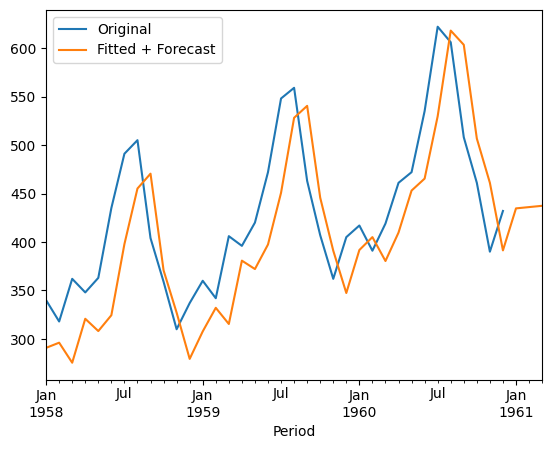

In [ ]:
y[-36:].plot(label='Original')
y_pred2[-39:].plot(label='Fitted + Forecast')
plt.legend()

The forecast looks similar, but the fitted values are definitely "off." Let's check the forecasts first:

In [ ]:
y_pred2[-3:].diff()

1961-01         NaN
1961-02    1.328592
1961-03    1.328592
Freq: M, Name: Number of airline passengers, dtype: float64

Same difference as before, good! However, there's a small twist in the way the `ThetaForecaster` computes the drift, as we can see in the code below:

In [ ]:
n_timepoints = len(y)
initial_level = forecaster2.initial_level_
drift = (np.array([-1, 0, 1, 2, 3]) + (1 - (1 - initial_level) ** n_timepoints) / initial_level) * lin0.coef_/2
drift

array([1.97975632e-08, 1.32859197e+00, 2.65718393e+00, 3.98577588e+00,
       5.31436784e+00])

So, what's actually happening here?

The `ThetaForecaster` uses the simplified SES with drift approach, which is fine for forecasting, but produces diverging values (from the traditional theta model, that is) if we try to use to predict past, realized, values.

Moreover, the SES produces a starting point for the forecasts which may slightly differ from that of the traditional theta model, even though the slope is exactly the same as we have seen above.

The plots below illustrate better the differences between the two methods:

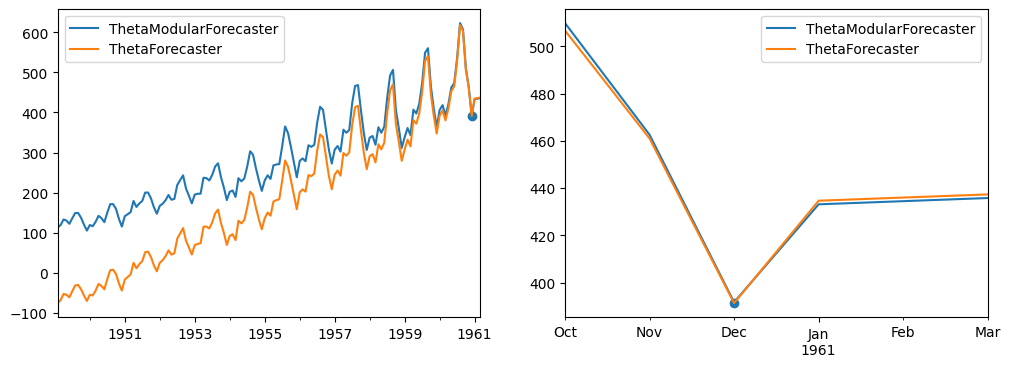

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
y_pred.plot(ax=axs[0], label='ThetaModularForecaster')
y_pred2.plot(ax=axs[0], label='ThetaForecaster')
axs[0].scatter(y_pred2.index[-4], y_pred2[-4])
axs[0].legend()
y_pred[-6:].plot(ax=axs[1], label='ThetaModularForecaster')
y_pred2[-6:].plot(ax=axs[1], label='ThetaForecaster')
axs[1].scatter(y_pred2.index[-4], y_pred2[-4])
axs[1].legend()